In [ ]:
!pip -q install timm==1.* scikit-learn==1.* pandas==2.* matplotlib==3.* tqdm==4.*

In [ ]:
import os, random, json
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image, ImageFile
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedShuffleSplit

In [ ]:
SEED = 1729

def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

seed_everything(SEED)

In [ ]:
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
# Drive + dataset root
from google.colab import drive
drive.mount("/content/drive")

CUB_ROOT = Path("/content/drive/MyDrive/CUB_200_2011")

# Where to write artifacts
ART_DIR = CUB_ROOT / "_artifacts"
ART_DIR.mkdir(parents=True, exist_ok=True)

print("CUB_ROOT:", CUB_ROOT)
print("ART_DIR :", ART_DIR)

Mounted at /content/drive
CUB_ROOT: /content/drive/MyDrive/CUB_200_2011
ART_DIR : /content/drive/MyDrive/CUB_200_2011/_artifacts


In [ ]:
# Metadata text files
images_txt  = CUB_ROOT / "images.txt"
labels_txt  = CUB_ROOT / "image_class_labels.txt"
split_txt   = CUB_ROOT / "train_test_split.txt"
bbox_txt    = CUB_ROOT / "bounding_boxes.txt"
classes_txt = CUB_ROOT / "classes.txt"

In [ ]:
def read_two_col(path: Path) -> pd.DataFrame:
    # Whitespace parsing for the CUB text files.
    return pd.read_csv(path, sep=r"\s+", header=None, engine="python")

In [ ]:
# images.txt: image_id, relative path under images/
df_images = read_two_col(images_txt).rename(columns={0: "image_id", 1: "rel_path"})
df_images["abs_path"] = df_images["rel_path"].apply(lambda p: str(CUB_ROOT / "images" / str(p)))

In [ ]:
# image_class_labels.txt: image_id, class_id
df_labels = read_two_col(labels_txt).rename(columns={0: "image_id", 1: "class_id"})

In [ ]:
# train_test_split.txt: image_id, is_training_image (1=train, 0=test)
df_split = read_two_col(split_txt).rename(columns={0: "image_id", 1: "is_train"})

In [ ]:
# bounding_boxes.txt: image_id, x, y, width, height (pixel units)
df_bbox = pd.read_csv(
    bbox_txt, sep=r"\s+", header=None, engine="python",
    names=["image_id", "x", "y", "w", "h"]
)

In [ ]:
# classes.txt: class_id, class_name
df_classes = pd.read_csv(
    classes_txt, sep=r"\s+", header=None, engine="python",
    names=["class_id", "class_name"]
)

In [ ]:
# Merge all metadata into a single table keyed by image_id
df = (
    df_images
    .merge(df_labels, on="image_id", how="inner")
    .merge(df_split,  on="image_id", how="inner")
    .merge(df_bbox,   on="image_id", how="inner")
    .merge(df_classes,on="class_id", how="left")
)

print("Merged df shape:", df.shape)
df.head()

Merged df shape: (11788, 10)


,image_id,rel_path,abs_path,class_id,is_train,x,y,w,h,class_name
0,1,001.Black_footed_Albatross/Black_Footed_Albatr...,/content/drive/MyDrive/CUB_200_2011/images/001...,1,0,60.0,27.0,325.0,304.0,001.Black_footed_Albatross
1,2,001.Black_footed_Albatross/Black_Footed_Albatr...,/content/drive/MyDrive/CUB_200_2011/images/001...,1,1,139.0,30.0,153.0,264.0,001.Black_footed_Albatross
2,3,001.Black_footed_Albatross/Black_Footed_Albatr...,/content/drive/MyDrive/CUB_200_2011/images/001...,1,0,14.0,112.0,388.0,186.0,001.Black_footed_Albatross
3,4,001.Black_footed_Albatross/Black_Footed_Albatr...,/content/drive/MyDrive/CUB_200_2011/images/001...,1,1,112.0,90.0,255.0,242.0,001.Black_footed_Albatross
4,5,001.Black_footed_Albatross/Black_Footed_Albatr...,/content/drive/MyDrive/CUB_200_2011/images/001...,1,1,70.0,50.0,134.0,303.0,001.Black_footed_Albatross


In [ ]:
# Integrity: missing image paths
missing = df["abs_path"].apply(lambda p: not os.path.exists(p)).sum()
print("Missing image files:", missing)

Missing image files: 0


In [ ]:
# Integrity: split values
print("Split values:", sorted(df["is_train"].unique().tolist()))

Split values: [0, 1]


In [ ]:
# Core counts
n_total = len(df)
n_train_official = int((df["is_train"] == 1).sum())
n_test_official  = int((df["is_train"] == 0).sum())
n_classes_total  = int(df["class_id"].nunique())

print("Total images:", n_total)
print("Official train images:", n_train_official)
print("Official test images :", n_test_official)
print("Total classes:", n_classes_total)

Total images: 11788
Official train images: 5994
Official test images : 5794
Total classes: 200


In [ ]:
# Class distribution (official train)
train_df = df[df["is_train"] == 1].copy()
class_counts = train_df["class_id"].value_counts().sort_index()
print("Train class count summary:")
print(class_counts.describe())

Train class count summary:
count    200.000000
mean      29.970000
std        0.171015
min       29.000000
25%       30.000000
50%       30.000000
75%       30.000000
max       30.000000
Name: count, dtype: float64


In [ ]:
# Bounding box stats
bbox_w = df["w"].to_numpy(dtype=np.float32)
bbox_h = df["h"].to_numpy(dtype=np.float32)
print("BBox width: mean", float(bbox_w.mean()), "p05/p95", np.quantile(bbox_w, [0.05, 0.95]).tolist())
print("BBox height: mean", float(bbox_h.mean()), "p05/p95", np.quantile(bbox_h, [0.05, 0.95]).tolist())

BBox width: mean 256.7472839355469 p05/p95 [126.0, 417.64999999999964]
BBox height: mean 231.9280548095703 p05/p95 [121.0, 381.0]


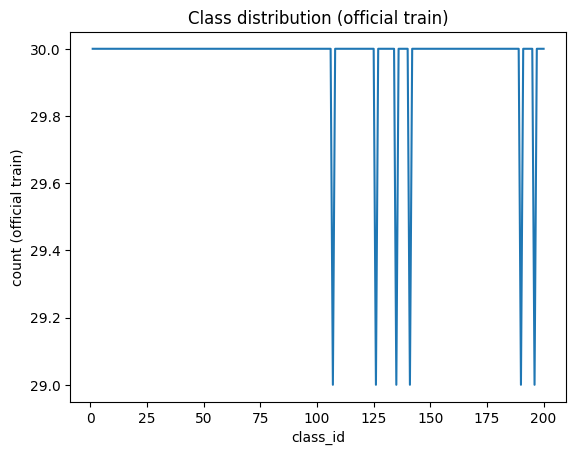

In [ ]:
# Plot: class distribution (official train)
plt.figure()
plt.plot(class_counts.index, class_counts.values)
plt.xlabel("class_id")
plt.ylabel("count (official train)")
plt.title("Class distribution (official train)")
plt.show()

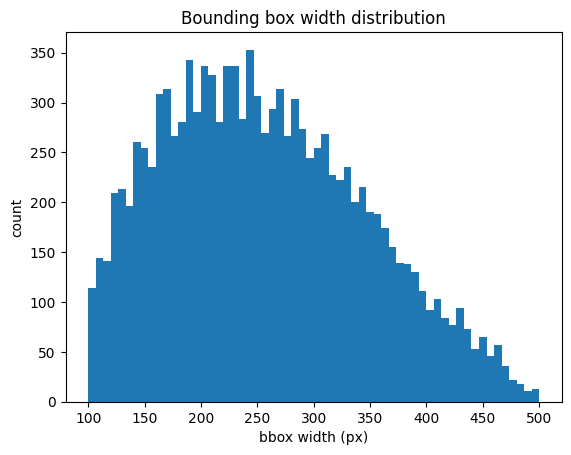

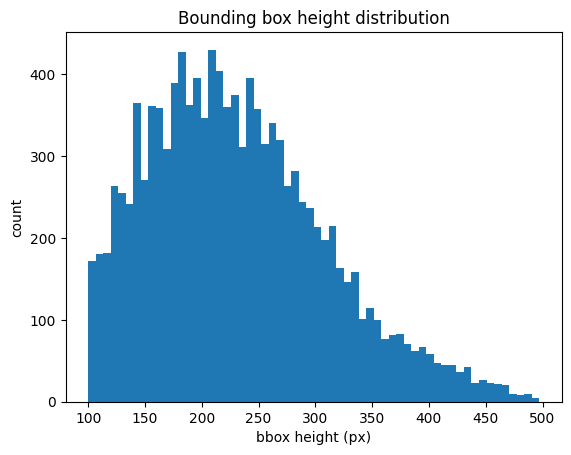

In [ ]:
# Plot: bbox width/height histograms
plt.figure()
plt.hist(df["w"].to_numpy(), bins=60)
plt.xlabel("bbox width (px)")
plt.ylabel("count")
plt.title("Bounding box width distribution")
plt.show()

plt.figure()
plt.hist(df["h"].to_numpy(), bins=60)
plt.xlabel("bbox height (px)")
plt.ylabel("count")
plt.title("Bounding box height distribution")
plt.show()

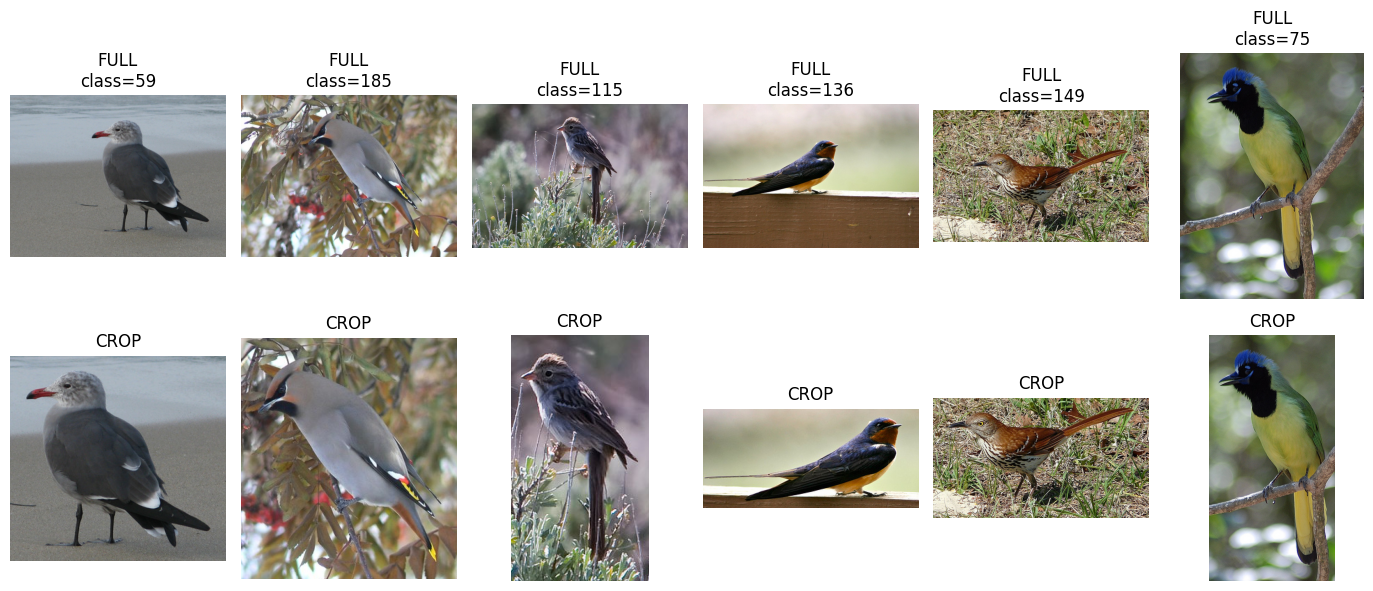

In [ ]:
# Sample a few images and show full + bbox crop
def show_samples_full_and_crop(frame: pd.DataFrame, n: int = 6, pad_frac: float = 0.08):
    sample = frame.sample(n, random_state=SEED).reset_index(drop=True)
    plt.figure(figsize=(14, 6))
    for i in range(n):
        r = sample.iloc[i]
        img = Image.open(r["abs_path"]).convert("RGB")

        x, y, w, h = float(r["x"]), float(r["y"]), float(r["w"]), float(r["h"])
        pad_w = pad_frac * w
        pad_h = pad_frac * h
        left   = max(0, int(x - pad_w))
        top    = max(0, int(y - pad_h))
        right  = min(img.width,  int(x + w + pad_w))
        bottom = min(img.height, int(y + h + pad_h))

        crop = img.crop((left, top, right, bottom))

        plt.subplot(2, n, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"FULL\nclass={int(r['class_id'])}")

        plt.subplot(2, n, n + i + 1)
        plt.imshow(crop)
        plt.axis("off")
        plt.title("CROP")

    plt.tight_layout()
    plt.show()

show_samples_full_and_crop(train_df, n=6, pad_frac=0.08)

In [ ]:
SPLIT_RATIO = 0.10

# official splits
train_df_official = df[df["is_train"] == 1].copy()
test_df_official  = df[df["is_train"] == 0].copy()

# stratified split on official train
idx = np.arange(len(train_df_official))
y = train_df_official["class_id"].to_numpy()

splitter = StratifiedShuffleSplit(n_splits=1, test_size=SPLIT_RATIO, random_state=SEED)
train_idx, val_idx = next(splitter.split(idx, y))

In [ ]:
train_ids = train_df_official.iloc[train_idx]["image_id"].to_numpy(dtype=np.int32)
val_ids   = train_df_official.iloc[val_idx]["image_id"].to_numpy(dtype=np.int32)
test_ids  = test_df_official["image_id"].to_numpy(dtype=np.int32)

# Verify every class appears in both train and val
train_classes = train_df_official[train_df_official["image_id"].isin(train_ids)]["class_id"].nunique()
val_classes   = train_df_official[train_df_official["image_id"].isin(val_ids)]["class_id"].nunique()
all_classes   = train_df_official["class_id"].nunique()

print("Classes in official train:", all_classes)
print("Classes in train split   :", train_classes)
print("Classes in val split     :", val_classes)

assert train_classes == all_classes, "Train split is missing at least one class."
assert val_classes == all_classes, "Val split is missing at least one class."

Classes in official train: 200
Classes in train split   : 200
Classes in val split     : 200


In [ ]:
# Save artifacts (reusable for ResNet, Swin, scratch model)
meta_csv = ART_DIR / "metadata.csv"
df.to_csv(meta_csv, index=False)

np.save(ART_DIR / "train_ids.npy", np.sort(train_ids))
np.save(ART_DIR / "val_ids.npy",   np.sort(val_ids))
np.save(ART_DIR / "test_ids.npy",  np.sort(test_ids))

eda_summary = {
    "seed": SEED,
    "val_ratio": SPLIT_RATIO,
    "n_total": int(len(df)),
    "n_train_official": int(len(train_df_official)),
    "n_test_official": int(len(test_df_official)),
    "n_classes_total": int(df["class_id"].nunique()),
    "n_train_ids": int(len(train_ids)),
    "n_val_ids": int(len(val_ids)),
    "n_test_ids": int(len(test_ids)),
}
with open(ART_DIR / "eda_summary.json", "w") as f:
    json.dump(eda_summary, f, indent=2)

print("Wrote:", meta_csv)
print("Wrote:", ART_DIR / "train_ids.npy")
print("Wrote:", ART_DIR / "val_ids.npy")
print("Wrote:", ART_DIR / "test_ids.npy")
print("Wrote:", ART_DIR / "eda_summary.json")

Wrote: /content/drive/MyDrive/CUB_200_2011/_artifacts/metadata.csv
Wrote: /content/drive/MyDrive/CUB_200_2011/_artifacts/train_ids.npy
Wrote: /content/drive/MyDrive/CUB_200_2011/_artifacts/val_ids.npy
Wrote: /content/drive/MyDrive/CUB_200_2011/_artifacts/test_ids.npy
Wrote: /content/drive/MyDrive/CUB_200_2011/_artifacts/eda_summary.json
